# Step 6: Statistical Test & Machine Learning Models
### DI 501 Term Project | Eda Yilmaz

**Goal:**
1. Apply Kruskal-Wallis test for RQ1 — yield instability across data-driven clusters
2. Train two ML models (Decision Tree, Random Forest) for RQ2
3. Evaluate performance per cluster before hyperparameter tuning

**Data:** Global CY-Bench dataset (38 countries, hemisphere-adjusted features)  
**Grouping variable:** Data-driven cluster (k=3, from step5b)  
**Selected features:** `heat_stress_days`, `prec_gs`  
**Target:** `detrended_yield`  
**ML exclusions:** Brazil (BR) and United States (US) — each dominates its cluster (98% and 81% of observations respectively), which would prevent the model from learning generalizable climate-yield relationships  
**Metrics:** RMSE, rRMSE

---

## 1. Load Data & Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scikit_posthocs import posthoc_dunn
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 120

SELECTED_FEATURES = ['heat_stress_days', 'prec_gs']
TARGET            = 'detrended_yield'
CLUSTERS          = [0, 1, 2]
CLUSTER_COLORS    = {0: '#e07b39', 1: '#3b82c4', 2: '#5aad5a'}
ML_EXCLUDE        = ['BR', 'US']   # excluded from ML training only

# ── Load global ML dataset (cluster labels added by step5b) ──────────────────
df_all = pd.read_csv('./master_global_ml_dataset.csv').dropna(
    subset=SELECTED_FEATURES + [TARGET]
)

# ── Load global CV dataset (cluster labels added by step5b) ─────────────────
cv_df = pd.read_csv('./cv_global_per_region.csv')

# ── ML training dataset: exclude BR and US ───────────────────────────────────
df = df_all[~df_all['country'].isin(ML_EXCLUDE)].copy()

print(f'Full dataset (all 38 countries):')
print(f'  {len(df_all):,} obs | {df_all["adm_id"].nunique():,} regions | {df_all["country"].nunique()} countries')
print()
print(f'ML training dataset (BR + US excluded):')
print(f'  {len(df):,} obs | {df["adm_id"].nunique():,} regions | {df["country"].nunique()} countries')
print()
print('ML training observations per cluster:')
print(df.groupby('cluster').agg(
    countries=('country', 'nunique'),
    regions=('adm_id', 'nunique'),
    obs=('adm_id', 'count')
).to_string())
print()
print('CV dataset (all 38 countries, for RQ1):')
print(cv_df.groupby('cluster').agg(regions=('adm_id', 'count')).to_string())

Full dataset (all 38 countries):
  157,894 obs | 8,768 regions | 38 countries

ML training dataset (BR + US excluded):
  30,278 obs | 1,959 regions | 36 countries

ML training observations per cluster:
         countries  regions    obs
cluster                           
0                8      507   8754
1               24     1342  20143
2                4      110   1381

CV dataset (all 38 countries, for RQ1):
         regions
cluster         
0           2830
1           1386
2           5580


---
## 2. RQ1 — Kruskal-Wallis Statistical Test

**H₀:** The distribution of maize yield instability (CV of detrended yield) does not differ across the 3 data-driven climate clusters.  
**H₁:** At least one cluster has a significantly different yield instability distribution.  
**Test:** Kruskal-Wallis H-test (non-parametric) | **α = 0.05**  
**Dataset:** All 38 countries (CV computed from full yield time series, all years)

In [13]:
# Shapiro-Wilk normality check per cluster
print('SHAPIRO-WILK NORMALITY TEST (CV per cluster)')
print()
for c in CLUSTERS:
    cv_vals = cv_df[cv_df['cluster'] == c]['cv'].dropna()
    stat, p = stats.shapiro(cv_vals[:5000])  # Shapiro-Wilk max 5000 samples
    normal = 'Normal' if p > 0.05 else 'NOT normal'
    print(f'  Cluster {c} (n={len(cv_vals):,}): W = {stat:.4f}, p = {p:.4f} → {normal}')

print()
print('Since at least one cluster is NOT normally distributed, Kruskal-Wallis is appropriate.')

SHAPIRO-WILK NORMALITY TEST (CV per cluster)

  Cluster 0 (n=2,830): W = 0.8704, p = 0.0000 → NOT normal
  Cluster 1 (n=1,386): W = 0.8502, p = 0.0000 → NOT normal
  Cluster 2 (n=5,580): W = 0.8405, p = 0.0000 → NOT normal

Since at least one cluster is NOT normally distributed, Kruskal-Wallis is appropriate.


In [14]:
groups = [cv_df[cv_df['cluster'] == c]['cv'].dropna() for c in CLUSTERS]
H_stat, p_value = stats.kruskal(*groups)

print('KRUSKAL-WALLIS H-TEST RESULTS')
print()
print(f'H statistic : {H_stat:.4f}')
print(f'p-value     : {p_value:.6f}')
print(f'Significance: α = 0.05')
print()
if p_value < 0.05:
    print('Result: REJECT H₀ — yield instability differs significantly across clusters (p < 0.05)')
else:
    print('Result: FAIL TO REJECT H₀ — no significant difference found (p ≥ 0.05)')
print()
print('Median CV per cluster:')
for c in CLUSTERS:
    sub = cv_df[cv_df['cluster'] == c]['cv'].dropna()
    print(f'  Cluster {c}: median = {sub.median():.1f}%  (n = {len(sub):,} regions)')

KRUSKAL-WALLIS H-TEST RESULTS

H statistic : 1195.2168
p-value     : 0.000000
Significance: α = 0.05

Result: REJECT H₀ — yield instability differs significantly across clusters (p < 0.05)

Median CV per cluster:
  Cluster 0: median = 17.8%  (n = 2,830 regions)
  Cluster 1: median = 17.4%  (n = 1,386 regions)
  Cluster 2: median = 24.8%  (n = 5,580 regions)


In [15]:
# Post-hoc Dunn test with Bonferroni correction
print('POST-HOC DUNN TEST (Bonferroni correction)')
print()

dunn_result = posthoc_dunn(
    cv_df, val_col='cv', group_col='cluster', p_adjust='bonferroni'
)

print(dunn_result.round(4).to_string())
print()
print('Values below 0.05 indicate significantly different pairs.')

POST-HOC DUNN TEST (Bonferroni correction)

     0    1    2
0  1.0  1.0  0.0
1  1.0  1.0  0.0
2  0.0  0.0  1.0

Values below 0.05 indicate significantly different pairs.


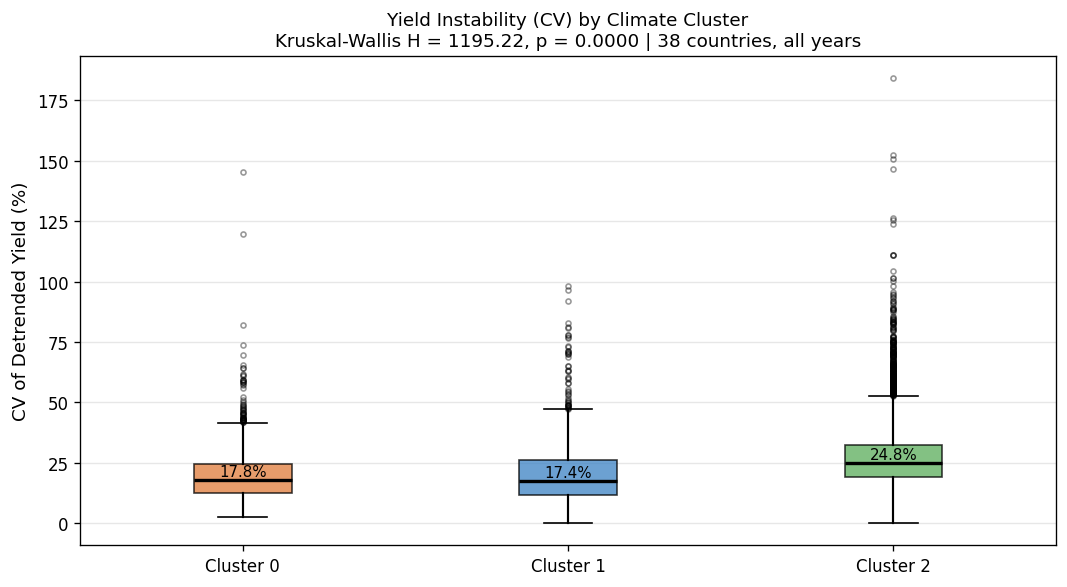

Saved: fig_cv_kruskal_global.png


In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

cluster_labels = [f'Cluster {c}' for c in CLUSTERS]
bp = ax.boxplot(
    [cv_df[cv_df['cluster'] == c]['cv'].dropna() for c in CLUSTERS],
    tick_labels=cluster_labels,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    whiskerprops={'linewidth': 1.3},
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
)
for patch, c in zip(bp['boxes'], CLUSTERS):
    patch.set_facecolor(CLUSTER_COLORS[c])
    patch.set_alpha(0.75)

for i, c in enumerate(CLUSTERS):
    med = cv_df[cv_df['cluster'] == c]['cv'].median()
    ax.text(i + 1, med + 0.5, f'{med:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('CV of Detrended Yield (%)', fontsize=11)
ax.set_title(f'Yield Instability (CV) by Climate Cluster\n'
             f'Kruskal-Wallis H = {H_stat:.2f}, p = {p_value:.4f} | 38 countries, all years',
             fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./fig_cv_kruskal_global.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_cv_kruskal_global.png')

---
## 3. RQ2 — ML Models

**Training data:** 36 countries (BR and US excluded)  
**Evaluation:** 5-fold cross-validation, results reported per cluster  
**Normalization:** StandardScaler fitted on train fold, applied to test fold

In [17]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def rrmse(y_true, y_pred, mean_yield):
    return (rmse(y_true, y_pred) / mean_yield) * 100

def evaluate_model(model, df, features, target, n_splits=5):
    """
    5-fold cross-validation with StandardScaler.
    Evaluates overall and per-cluster RMSE and rRMSE.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X = df[features].values
    y = df[target].values

    all_preds = np.zeros(len(df))
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)
        model.fit(X_train, y_train)
        all_preds[test_idx] = model.predict(X_test)

    df = df.copy()
    df['y_pred'] = all_preds

    results = []
    for c in CLUSTERS:
        sub = df[df['cluster'] == c]
        if len(sub) == 0:
            continue
        mean_yield = sub['yield'].mean()
        results.append({
            'Cluster':      f'Cluster {c}',
            'N':            len(sub),
            'RMSE (t/ha)':  round(rmse(sub[target].values, sub['y_pred'].values), 3),
            'rRMSE (%)':    round(rrmse(sub[target].values, sub['y_pred'].values, mean_yield), 2)
        })

    return pd.DataFrame(results), df

print('Metric functions and evaluation pipeline defined.')

Metric functions and evaluation pipeline defined.


### 3.1 Model 1 — Decision Tree (default parameters)

In [18]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_results, dt_df = evaluate_model(dt_model, df, SELECTED_FEATURES, TARGET)

print('DECISION TREE — Performance before tuning (5-fold CV)')
print('Training: 36 countries (BR + US excluded)')
print()
print(dt_results.to_string(index=False))

DECISION TREE — Performance before tuning (5-fold CV)
Training: 36 countries (BR + US excluded)

  Cluster     N  RMSE (t/ha)  rRMSE (%)
Cluster 0  8754        1.508      32.28
Cluster 1 20143        1.489      26.36
Cluster 2  1381        1.047      58.75


### 3.2 Model 2 — Random Forest (default parameters)

In [19]:
rf_model = RandomForestRegressor(random_state=42)
rf_results, rf_df = evaluate_model(rf_model, df, SELECTED_FEATURES, TARGET)

print('RANDOM FOREST — Performance before tuning (5-fold CV)')
print('Training: 36 countries (BR + US excluded)')
print()
print(rf_results.to_string(index=False))

RANDOM FOREST — Performance before tuning (5-fold CV)
Training: 36 countries (BR + US excluded)

  Cluster     N  RMSE (t/ha)  rRMSE (%)
Cluster 0  8754        1.182      25.30
Cluster 1 20143        1.165      20.63
Cluster 2  1381        0.772      43.31


---
## 4. Comparison with Naive Baseline

In [21]:
naive_results = []
for c in CLUSTERS:
    sub = df[df['cluster'] == c]
    if len(sub) == 0:
        continue
    mean_yield = sub['yield'].mean()
    naive_results.append({
        'Cluster':      f'Cluster {c}',
        'N':            len(sub),
        'RMSE (t/ha)':  round(rmse(sub[TARGET].values, np.zeros(len(sub))), 3),
        'rRMSE (%)':    round(rrmse(sub[TARGET].values, np.zeros(len(sub)), mean_yield), 2)
    })
naive_df = pd.DataFrame(naive_results)

print('COMPARISON: Naive Baseline vs Decision Tree vs Random Forest')
print('(36 countries — BR and US excluded from training)')
print()
print('--- NAIVE BASELINE (predict detrended_yield = 0 for all) ---')
print(naive_df.to_string(index=False))
print()
print('--- DECISION TREE ---')
print(dt_results.to_string(index=False))
print()
print('--- RANDOM FOREST ---')
print(rf_results.to_string(index=False))

COMPARISON: Naive Baseline vs Decision Tree vs Random Forest
(36 countries — BR and US excluded from training)

--- NAIVE BASELINE (predict detrended_yield = 0 for all) ---
  Cluster     N  RMSE (t/ha)  rRMSE (%)
Cluster 0  8754        1.184      25.34
Cluster 1 20143        1.058      18.74
Cluster 2  1381        0.563      31.56

--- DECISION TREE ---
  Cluster     N  RMSE (t/ha)  rRMSE (%)
Cluster 0  8754        1.508      32.28
Cluster 1 20143        1.489      26.36
Cluster 2  1381        1.047      58.75

--- RANDOM FOREST ---
  Cluster     N  RMSE (t/ha)  rRMSE (%)
Cluster 0  8754        1.182      25.30
Cluster 1 20143        1.165      20.63
Cluster 2  1381        0.772      43.31


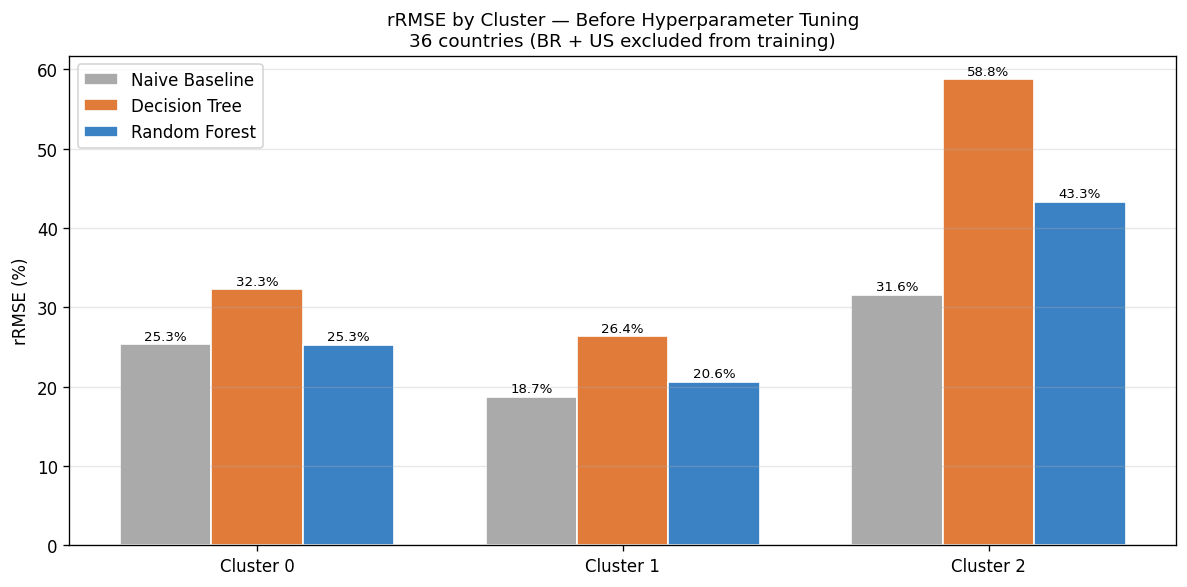

Saved: fig_model_comparison_pretune_global.png


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

cluster_labels = [f'Cluster {c}' for c in CLUSTERS]
x = np.arange(len(CLUSTERS))
width = 0.25

bars1 = ax.bar(x - width, naive_df['rRMSE (%)'], width, label='Naive Baseline',
               color='#aaaaaa', edgecolor='white')
bars2 = ax.bar(x,          dt_results['rRMSE (%)'], width, label='Decision Tree',
               color='#e07b39', edgecolor='white')
bars3 = ax.bar(x + width,  rf_results['rRMSE (%)'], width, label='Random Forest',
               color='#3b82c4', edgecolor='white')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(cluster_labels)
ax.set_ylabel('rRMSE (%)')
ax.set_title('rRMSE by Cluster — Before Hyperparameter Tuning\n'
             '36 countries (BR + US excluded from training)', fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./fig_model_comparison_pretune_global.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_model_comparison_pretune_global.png')

---
## 5. Summary

| Item | Value |
|---|---|
| RQ1 dataset | All 38 countries, CV grouped by cluster |
| RQ2 training dataset | 36 countries (BR + US excluded) |
| Grouping variable | Data-driven cluster (k=3) |
| Features | `heat_stress_days`, `prec_gs` |
| KW result | See output above |
| Model results | See output above — to be completed after running |

**Next step:** Hyperparameter tuning (Step 7) to improve model performance.

---